# Opioids Project: Analysis

Ra'Kira Nelson and Alexa Fahrer

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import seaborn.objects as so
import seaborn_objects_recipes as sor
import matplotlib.pyplot as plt

pd.set_option("mode.copy_on_write", True)

In [2]:
opioids_prescriptions = pd.read_csv("data/opioids_clean.csv")
opioids_prescriptions = opioids_prescriptions.copy()
opioids_prescriptions = opioids_prescriptions.drop(columns=["Unnamed: 0"])

In [3]:
opioids_deaths = pd.read_csv("data/opioids_deaths.csv")
opioids_deaths = opioids_deaths.copy()
opioids_deaths = opioids_deaths.drop(columns=["Unnamed: 0"])

## Control States

In [4]:
# 2 different sets of control states for prescription shipments and overdose

# control states for prescription shipments: Ohio, Alabama, Georgia, Kentucky
control_states_prescriptions = [
    "OHIO",
    "ALABAMA",
    "GEORGIA",
    "KENTUCKY",
]
opioids_states_prescriptions = opioids_prescriptions[
    opioids_prescriptions["state"].isin(control_states_prescriptions + ["FLORIDA"])
]

# control states for overdoses: Colorado, Michigan, Pennsylvania
control_states_od = ["COLORADO", "MICHIGAN", "PENNSYLVANIA"]
opioids_states_od = opioids_deaths[
    opioids_deaths["state"].isin(control_states_od + ["FLORIDA"])
]

## Plots

### Pre-Trend Checks: Florida vs Control States

Control states for MME: Ohio, Alabama, Georgia, Kentucky

Control states for overdoses: Colorado, Michigan, Pennsylvania

In [5]:
# initialized df & vars for analyses

pre_prescriptions = opioids_states_prescriptions[
    opioids_states_prescriptions["year"] < 2010
]

post_prescriptions = opioids_states_prescriptions[
    opioids_states_prescriptions["year"] >= 2010
]

pre_overdose = opioids_states_od[opioids_states_od["year"] < 2010]

post_overdose = opioids_states_od[opioids_states_od["year"] >= 2010]

color_map = {True: "tab:orange", False: "tab:blue"}

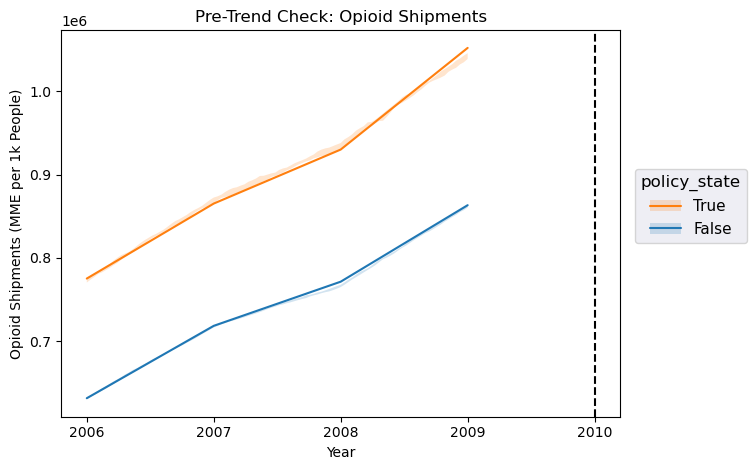

In [6]:
# Pre-Trend Check: MME per 1000

fig1, ax1 = plt.subplots()

plot = (
    so.Plot(pre_prescriptions, x="year", y="mme_per_1000", color="policy_state")
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        title="Pre-Trend Check: Opioid Shipments",
        x="Year",
        y="Opioid Shipments (MME per 1k People)",
    )
)

plot.on(ax1).plot()
plt.axvline(2010, color="black", linestyle="--")
plt.xticks(range(pre_prescriptions["year"].min(), pre_prescriptions["year"].max() + 2))
plt.tight_layout()
plt.show()

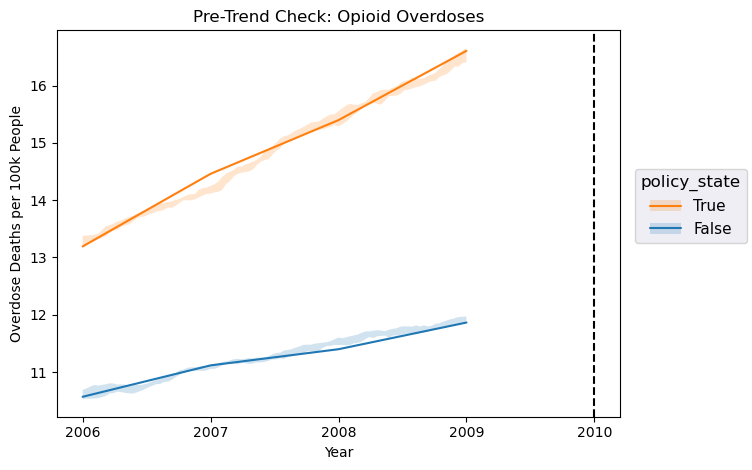

In [7]:
# Pre-Trend Check: Overdoses per 100k

fig2, ax2 = plt.subplots()

plot = (
    so.Plot(pre_overdose, x="year", y="overdose_per_100k", color="policy_state")
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
    .label(
        title="Pre-Trend Check: Opioid Overdoses",
        x="Year",
        y="Overdose Deaths per 100k People",
    )
)

plot.on(ax2).plot()
plt.axvline(2010, color="black", linestyle="--")
plt.xticks(range(pre_overdose["year"].min(), pre_overdose["year"].max() + 2))
plt.tight_layout()
plt.show()

### Pre-Post: Florida

In [8]:
# initialize dfs for pre-post florida analysis

# MME
fl_prescriptions = opioids_states_prescriptions[
    opioids_states_prescriptions["state"] == "FLORIDA"
]

pre_fl_prescriptions = fl_prescriptions[fl_prescriptions["year"] < 2010]
post_fl_prescriptions = fl_prescriptions[fl_prescriptions["year"] >= 2010]

# Overdoses
fl_overdose = opioids_states_od[opioids_states_od["state"] == "FLORIDA"]

pre_fl_overdose = fl_overdose[fl_overdose["year"] < 2010]
post_fl_overdose = fl_overdose[fl_overdose["year"] >= 2010]

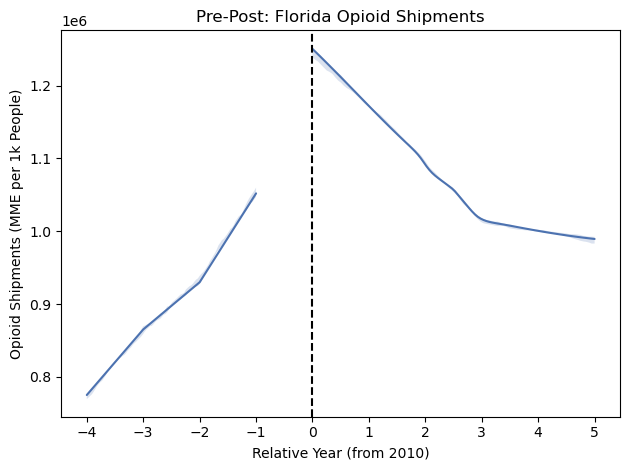

In [9]:
# Pre-Post: Florida MME

fig_mme, ax3 = plt.subplots()

pre_fl_plot = (
    so.Plot(pre_fl_prescriptions, x="relative_year", y="mme_per_1000")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
)

post_fl_plot = (
    so.Plot(post_fl_prescriptions, x="relative_year", y="mme_per_1000")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
)


pre_fl_plot.on(ax3).plot()
post_fl_plot.on(ax3).plot()
plt.title("Pre-Post: Florida Opioid Shipments")
plt.xlabel("Relative Year (from 2010)")
plt.ylabel("Opioid Shipments (MME per 1k People)")
plt.axvline(0, color="black", linestyle="--")
plt.xticks(
    range(
        fl_prescriptions["relative_year"].min(),
        fl_prescriptions["relative_year"].max() + 1,
    )
)
plt.tight_layout()
plt.show()

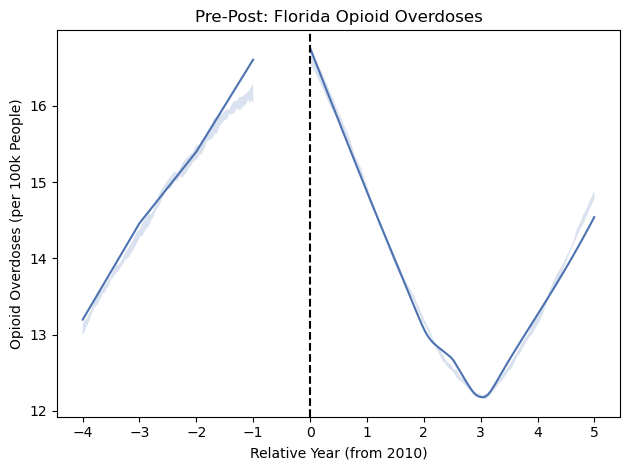

In [10]:
# Pre-Post: Florida Opioid Overdoses

fig_od, ax4 = plt.subplots()

pre_fl_plot = (
    so.Plot(pre_fl_overdose, x="relative_year", y="overdose_per_100k")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
)

post_fl_plot = (
    so.Plot(post_fl_overdose, x="relative_year", y="overdose_per_100k")
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
    )
    .add(so.Band(), lowess)
)

pre_fl_plot.on(ax4).plot()
post_fl_plot.on(ax4).plot()

plt.title("Pre-Post: Florida Opioid Overdoses")
plt.xlabel("Relative Year (from 2010)")
plt.ylabel("Opioid Overdoses (per 100k People)")
plt.axvline(0, color="black", linestyle="--")
plt.xticks(
    range(fl_overdose["relative_year"].min(), fl_overdose["relative_year"].max() + 1)
)
plt.tight_layout()
plt.show()

### Difference-in-Difference

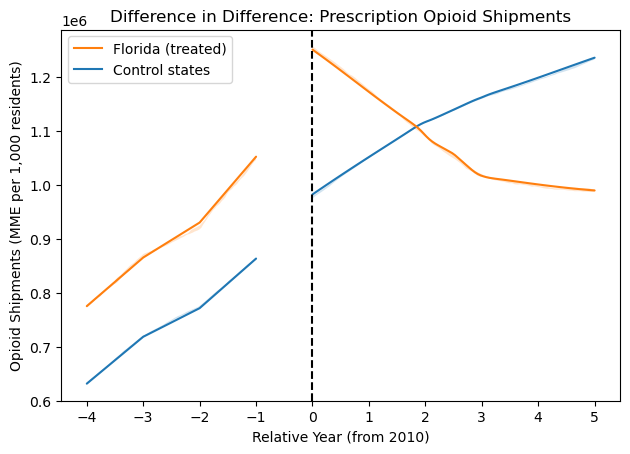

In [11]:
# Difference in Difference: MME

plot_pre = (
    so.Plot(
        pre_prescriptions, x="relative_year", y="mme_per_1000", color="policy_state"
    )
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
        legend=False,  # remove legend
    )
    .add(
        so.Band(),
        lowess,
        legend=False,  # remove legend
    )
)

plot_post = (
    so.Plot(
        post_prescriptions, x="relative_year", y="mme_per_1000", color="policy_state"
    )
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
        legend=False,
    )
    .add(so.Band(), lowess, legend=False)
)

# convert to matplotlib
fig_pres, ax_pres = plt.subplots()

plot_pre.on(ax_pres).plot()
plot_post.on(ax_pres).plot()

ax_pres.axvline(0, color="black", linestyle="--")
ax_pres.set(
    title="Difference in Difference: Prescription Opioid Shipments",
    xlabel="Relative Year (from 2010)",
    ylabel="Opioid Shipments (MME per 1,000 residents)",
    xticks=sorted(opioids_states_prescriptions["relative_year"].unique()),
)

# setting new labels w/ matplotlib
handles = [
    plt.Line2D([], [], color="tab:orange", label="Florida (treated)"),
    plt.Line2D([], [], color="tab:blue", label="Control states"),
]
ax_pres.legend(handles=handles)

plt.tight_layout()
plt.show()

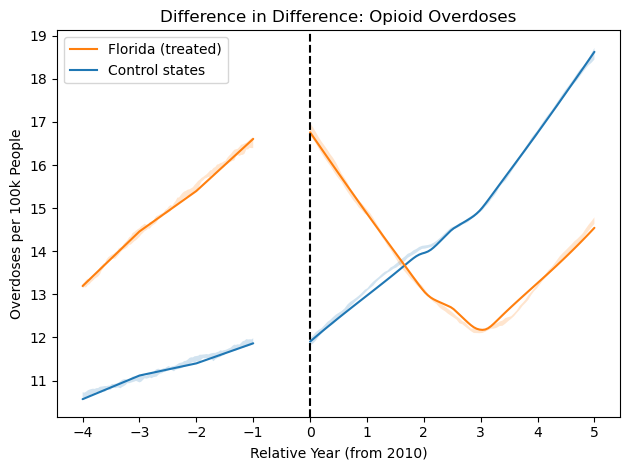

In [12]:
# Difference in Difference: Overdoses

plot_pre = (
    so.Plot(
        pre_overdose, x="relative_year", y="overdose_per_100k", color="policy_state"
    )
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
        legend=False,
    )
    .add(
        so.Band(),
        lowess,
        legend=False,
    )
)

plot_post = (
    so.Plot(
        post_overdose, x="relative_year", y="overdose_per_100k", color="policy_state"
    )
    .scale(color=color_map)
    .add(
        so.Line(),
        lowess := sor.Lowess(frac=0.7, gridsize=100, num_bootstrap=200, alpha=0.95),
        legend=False,
    )
    .add(so.Band(), lowess, legend=False)
)

# convert to matplotlib
fig_od, ax_od = plt.subplots()

plot_pre.on(ax_od).plot()
plot_post.on(ax_od).plot()

ax_od.axvline(0, color="black", linestyle="--")
ax_od.set(
    title="Difference in Difference: Opioid Overdoses",
    xlabel="Relative Year (from 2010)",
    ylabel="Overdoses per 100k People",
    xticks=sorted(opioids_states_od["relative_year"].unique()),
)

# setting new labels w/ matplotlib
handles = [
    plt.Line2D([], [], color="tab:orange", label="Florida (treated)"),
    plt.Line2D([], [], color="tab:blue", label="Control states"),
]
ax_od.legend(handles=handles)

plt.tight_layout()
plt.show()